# Imports & Environment Setup

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import quad
import scipy.linalg as la
import matplotlib.pyplot as plt

import emcee
import corner
import os
import time
from multiprocess import Pool, cpu_count

# Create necessary directories for outputs
os.makedirs("mcmc_chains", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Prevent internal SciPy/NumPy multithreading conflicts during MCMC parallelization
os.environ["OMP_NUM_THREADS"] = "1"
print("Environment initialized successfully.")

Environment initialized successfully.


# Load All 3 Datasets with Robust Type-Casting

In [2]:
# ---------------------------------------------------------
# 1. Load Pantheon+SH0ES Supernovae Data & Covariance
# ---------------------------------------------------------
df_sn = pd.read_csv('../../data/Pantheon+SH0ES.dat', sep=r'\s+')
N_sn = len(df_sn)

with open('../../data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
if len(lines[0].split()) == 1: 
    lines = lines[1:]
    
C_sn = np.loadtxt(lines).reshape((N_sn, N_sn))
c_chol_sn, lower_sn = la.cho_factor(C_sn)
C_inv_sn = la.cho_solve((c_chol_sn, lower_sn), np.eye(N_sn))
log_det_C_sn = 2.0 * np.sum(np.log(np.diag(c_chol_sn)))

print(f"✅ Pantheon+ SNe dataset loaded: {N_sn} supernovae.")

# ---------------------------------------------------------
# ANCHOR M_B EXPLICITLY FROM CEPHEID CALIBRATORS
# ---------------------------------------------------------
calibrators = df_sn[df_sn['IS_CALIBRATOR'] == 1]
M_B_values = calibrators['m_b_corr'] - calibrators['CEPH_DIST']
M_B_fixed = np.mean(M_B_values)
print(f"✅ M_B anchored from Cepheid calibrators: M_B = {M_B_fixed:.4f} mag")

# ---------------------------------------------------------
# 2. Load Cosmic Chronometers (CC) Data (With Type-Casting)
# ---------------------------------------------------------
try:
    df_cc = pd.read_csv('../../data/CC.txt', sep=r'\s+', comment='#', names=['z', 'Hz', 'err_Hz'])
except FileNotFoundError:
    df_cc = pd.read_csv('../../data/CC.txt', sep=r'\s+')

for col in ['z', 'Hz', 'err_Hz']:
    df_cc[col] = pd.to_numeric(df_cc[col], errors='coerce')
df_cc = df_cc.dropna().reset_index(drop=True)

N_cc = len(df_cc)
print(f"✅ Cosmic Chronometer dataset loaded and type-casted: {N_cc} data points.")

# ---------------------------------------------------------
# 3. Load DESI BAO Data & Covariance (With Type-Casting)
# ---------------------------------------------------------
df_bao = pd.read_csv(
    '../../data/desi_gaussian_bao_ALL_GCcomb_mean.txt', 
    sep=r'\s+', 
    comment='#', 
    names=['z', 'measurement', 'observable_type']
)

df_bao['z'] = pd.to_numeric(df_bao['z'], errors='coerce')
df_bao['measurement'] = pd.to_numeric(df_bao['measurement'], errors='coerce')
df_bao = df_bao.dropna().reset_index(drop=True)
N_bao = len(df_bao)

C_bao = np.loadtxt('../../data/desi_gaussian_bao_ALL_GCcomb_cov.txt').reshape((N_bao, N_bao))
c_chol_bao, lower_bao = la.cho_factor(C_bao)
C_inv_bao = la.cho_solve((c_chol_bao, lower_bao), np.eye(N_bao))
log_det_C_bao = 2.0 * np.sum(np.log(np.diag(c_chol_bao)))

print(f"✅ DESI BAO dataset loaded and type-casted: {N_bao} data points.")

✅ Pantheon+ SNe dataset loaded: 1701 supernovae.
✅ M_B anchored from Cepheid calibrators: M_B = -19.2715 mag
✅ Cosmic Chronometer dataset loaded and type-casted: 32 data points.
✅ DESI BAO dataset loaded and type-casted: 13 data points.


# CPL Physics & Full Joint Likelihood Engine (6 Parameters)

In [3]:
# ---------------------------------------------------------
# CPL Physics & Full Joint Likelihood Engine (5 Parameters)
# ---------------------------------------------------------
c = 299792.458  # Speed of light in km/s

def E_inverse(z, Omega_m, w0, wa):
    """Inverse dimensionless Hubble parameter 1/E(z) for CPL dark energy."""
    term_matter = Omega_m * (1.0 + z)**3
    exponent = 3.0 * (1.0 + w0 + wa)
    exponential_term = np.exp(-3.0 * wa * (z / (1.0 + z)))
    term_de = (1.0 - Omega_m) * ((1.0 + z)**exponent) * exponential_term
    return 1.0 / np.sqrt(term_matter + term_de)

def comoving_distance_mpc(z, H_0, Omega_m, w0, wa):
    """Line-of-sight comoving distance D_C in Mpc."""
    integral, _ = quad(E_inverse, 0, z, args=(Omega_m, w0, wa))
    return (c / H_0) * integral

def luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m, w0, wa):
    """Luminosity distance accounting for heliocentric and CMB redshifts."""
    return (1.0 + z_hel) * comoving_distance_mpc(z_cmb, H_0, Omega_m, w0, wa)

def model_cosmology_sn(z_hel, z_cmb, H_0, Omega_m, w0, wa):
    """Theoretical distance modulus m_b for SNe explicitly utilizing M_B_fixed."""
    d_L = luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m, w0, wa)
    return M_B_fixed + 5.0 * np.log10(d_L) + 25.0

def H_CPL(z, Omega_m, H_0, w0, wa):
    """Hubble rate H(z) in km/s/Mpc."""
    return H_0 / E_inverse(z, Omega_m, w0, wa)

def D_M(z, H_0, Omega_m, w0, wa):
    """Transverse comoving distance in a flat universe."""
    return comoving_distance_mpc(z, H_0, Omega_m, w0, wa)

def D_H(z, H_0, Omega_m, w0, wa):
    """Hubble distance c / H(z)."""
    return c / H_CPL(z, Omega_m, H_0, w0, wa)

def D_V(z, H_0, Omega_m, w0, wa):
    """Spherically averaged volume distance."""
    dm = D_M(z, H_0, Omega_m, w0, wa)
    dh = D_H(z, H_0, Omega_m, w0, wa)
    return np.cbrt(z * (dm**2) * dh)

def bao_theory(z, obs_type, H_0, Omega_m, r_d, w0, wa):
    """Maps theoretical distances to specific BAO observable ratios."""
    if obs_type == 'DV_over_rs':
        return D_V(z, H_0, Omega_m, w0, wa) / r_d
    elif obs_type == 'DM_over_rs':
        return D_M(z, H_0, Omega_m, w0, wa) / r_d
    elif obs_type == 'DH_over_rs':
        return D_H(z, H_0, Omega_m, w0, wa) / r_d
    else:
        raise ValueError(f"Unknown BAO observable type: {obs_type}")

def log_prior(params):
    # Only 5 parameters since M_B is fixed
    Omega_m, H_0, r_d, w0, wa = params
    
    bounds_check = (
        (0.01 < Omega_m < 0.99) and 
        (50.0 < H_0 < 100.0) and 
        (100.0 < r_d < 180.0) and 
        (-3.0 < w0 < 1.0) and 
        (-3.0 < wa < 3.0)
    )
    if not bounds_check:
        return -np.inf
        
    # Flat prior returned; no M_B Gaussian penalty needed
    return 0.0

def log_posterior_joint(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
        
    Omega_m, H_0, r_d, w0, wa = params
    
    # --- 1. SNe Log-Likelihood ---
    delta_sn = np.zeros(N_sn)
    for i, row in df_sn.iterrows():
        if row['IS_CALIBRATOR'] == 1:
            # For calibrators, use the geometric Cepheid distance along with M_B_fixed
            m_b_th = M_B_fixed + row['CEPH_DIST']
        else:
            # For Hubble flow SNe, use CPL cosmology model
            m_b_th = model_cosmology_sn(row['zHEL'], row['zCMB'], H_0, Omega_m, w0, wa)
            
        delta_sn[i] = row['m_b_corr'] - m_b_th
        
    chi2_sn = np.dot(delta_sn.T, np.dot(C_inv_sn, delta_sn))
    ll_sn = -0.5 * (chi2_sn + log_det_C_sn + N_sn * np.log(2.0 * np.pi))
    
    # --- 2. CC Log-Likelihood ---
    Hz_th = H_CPL(df_cc['z'].values, Omega_m, H_0, w0, wa)
    residuals_cc = df_cc['Hz'].values - Hz_th
    chi2_cc = np.sum((residuals_cc / df_cc['err_Hz'].values)**2)
    ll_cc = -0.5 * (chi2_cc + np.sum(np.log(2.0 * np.pi * (df_cc['err_Hz'].values**2))))
    
    # --- 3. BAO Log-Likelihood ---
    delta_bao = np.zeros(N_bao)
    for i, row in df_bao.iterrows():
        th_val = bao_theory(row['z'], row['observable_type'], H_0, Omega_m, r_d, w0, wa)
        delta_bao[i] = row['measurement'] - th_val
    chi2_bao = np.dot(delta_bao.T, np.dot(C_inv_bao, delta_bao))
    ll_bao = -0.5 * (chi2_bao + log_det_C_bao + N_bao * np.log(2.0 * np.pi))
    
    # --- 4. Return Full Combined Posterior ---
    return lp + ll_sn + ll_cc + ll_bao

# MCMC Execution with Gelman-Rubin Convergence

In [4]:
# ---------------------------------------------------------
# MCMC Execution with Gelman-Rubin Early Stopping
# ---------------------------------------------------------
def compute_gelman_rubin(chain):
    """Calculates R-hat convergence diagnostic across all parameter dimensions."""
    nsteps, nwalkers, ndim = chain.shape
    R_hat = np.zeros(ndim)
    for d in range(ndim):
        samples = chain[:, :, d]
        W = np.mean(np.var(samples, axis=0, ddof=1))
        chain_means = np.mean(samples, axis=0)
        grand_mean = np.mean(chain_means)
        B = (nsteps / (nwalkers - 1.0)) * np.sum((chain_means - grand_mean)**2)
        V_hat = ((nsteps - 1.0) / nsteps) * W + (B / nsteps)
        R_hat[d] = np.sqrt(V_hat / W) if W > 0 else np.inf
    return R_hat

# Configuration for 5D (M_B is fixed!)
ndim = 5  # (Omega_m, H_0, r_d, w0, wa)
nwalkers = 64
max_steps = 35000
check_interval = 200
R_hat_threshold = 1.02 

# Define prior bounding ranges for uniform random initialization
prior_bounds = [
    (0.20, 0.40),    # Omega_m
    (65.0, 78.0),    # H_0
    (135.0, 155.0),  # r_d
    (-1.5, -0.5),    # w0
    (-1.5, 1.5)      # wa
]

# Initialize walkers uniformly across the parameter space
initial_pos = np.zeros((nwalkers, ndim))
for i in range(ndim):
    low, high = prior_bounds[i]
    initial_pos[:, i] = np.random.uniform(low, high, size=nwalkers)

print("Walkers initialized uniformly across prior boundaries.")

# Set up HDF5 backend for permanent disk storage
h5_filename = "mcmc_chains/SNe_CC_BAO.h5"
backend = emcee.backends.HDFBackend(h5_filename)
backend.reset(nwalkers, ndim)

ncpu = int(max(1, cpu_count() - 1))
print(f"\nStarting Full 3-Way Joint MCMC (Fixed M_B) on {ncpu} cores (Max {max_steps} steps)...")

start_time = time.time()
with Pool(processes=ncpu) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_posterior_joint, 
        pool=pool, backend=backend
    )
    
    for sample in sampler.sample(initial_pos, iterations=max_steps, progress=True,progress_kwargs={"bar_format": "{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_noinv_fmt}]"}):
        if sampler.iteration % check_interval == 0 and sampler.iteration > 0:
            chain = sampler.get_chain()
            burn_in = int(chain.shape[0] * 0.5)
            R_hat = compute_gelman_rubin(chain[burn_in:, :, :])
            
            if np.all(R_hat < R_hat_threshold):
                print(f"\n✅ Gelman-Rubin convergence achieved at step {sampler.iteration}!")
                print(f"Final R-hat values: {np.round(R_hat, 4)}")
                break

end_time = time.time()
print(f"\nMCMC complete! Time taken: {(end_time - start_time) / 60:.2f} minutes.")
print(f"Master chain saved permanently to: {h5_filename}")

Walkers initialized uniformly across prior boundaries.

Starting Full 3-Way Joint MCMC (Fixed M_B) on 19 cores (Max 35000 steps)...


 17%|█████▎                          | 5800/35000 [3:05:20<15:33:03,  0.52it/s]


✅ Gelman-Rubin convergence achieved at step 5800!
Final R-hat values: [1.0197 1.0105 1.0089 1.0104 1.016 ]

MCMC complete! Time taken: 185.37 minutes.
Master chain saved permanently to: mcmc_chains/SNe_CC_BAO.h5


# Read from .h5 File & Plot Continuous Master Constraints

Successfully loaded mcmc_chains/SNe_CC_BAO.h5
Chain Dimensions -> Steps: 5800, Walkers: 64, Params: 5
Trace plot saved to: plots/SNe_CC_BAO_trace.png


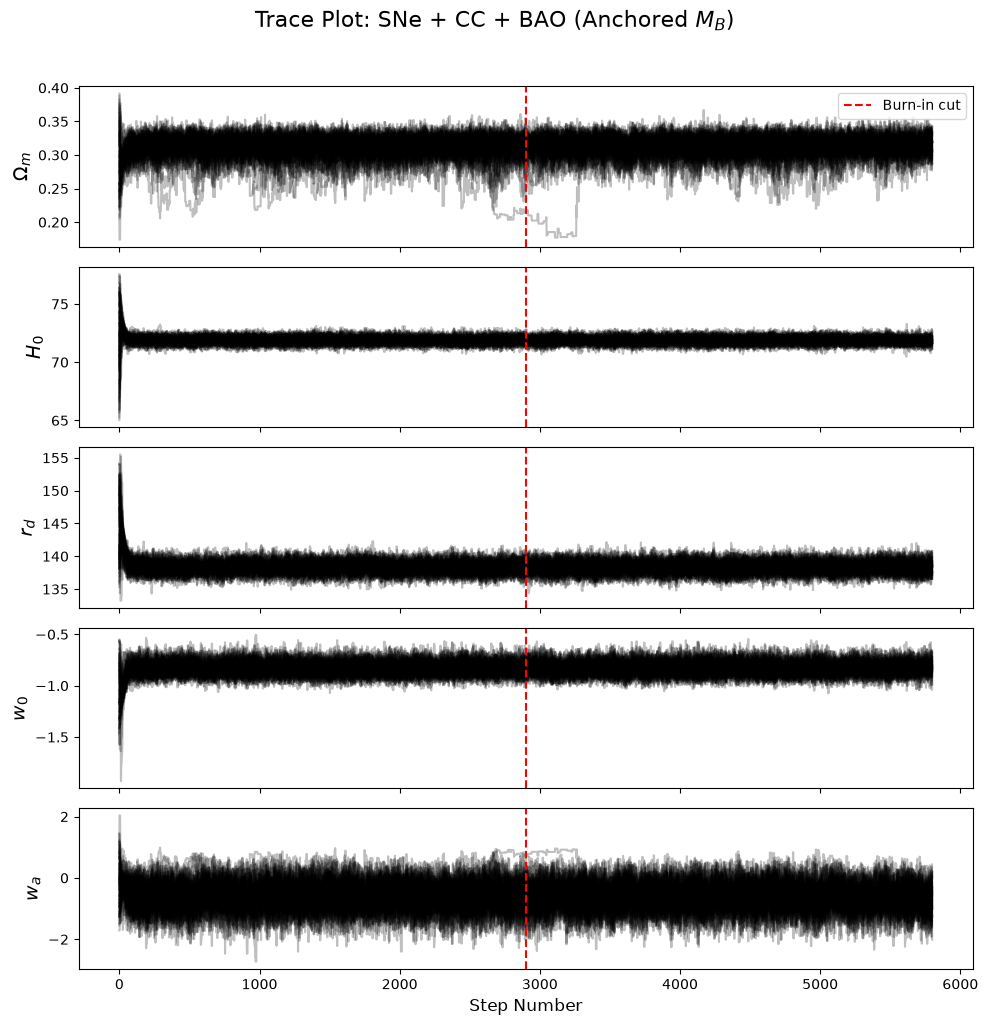

Continuous corner plot saved to: plots/SNe_CC_BAO_corner.png


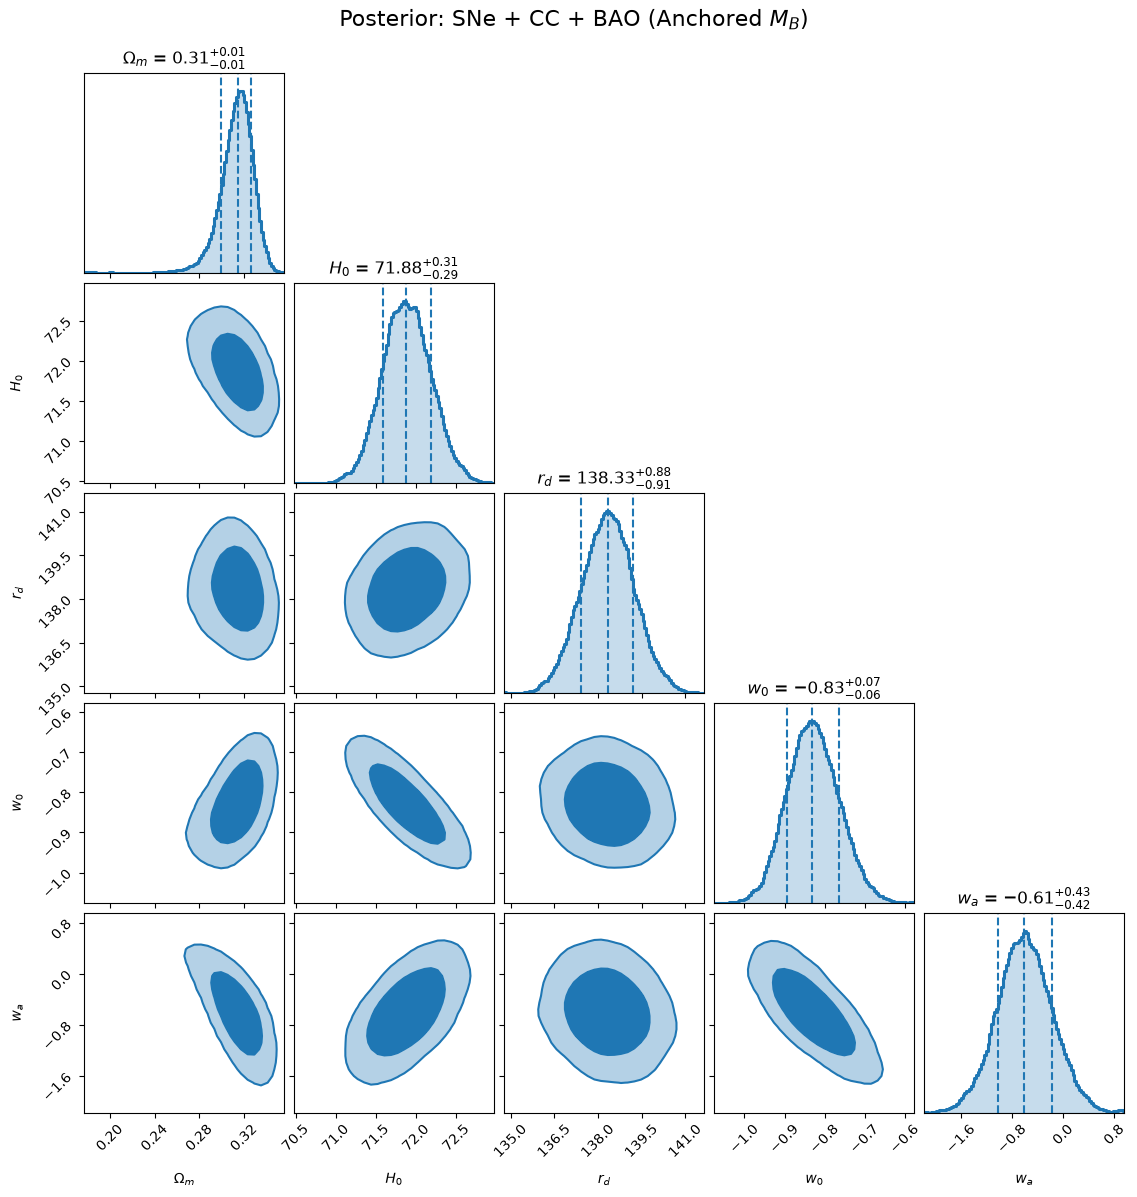

In [5]:
# ---------------------------------------------------------
# Read Directly from .h5 File & Plot Diagnostics
# ---------------------------------------------------------
h5_filename = "mcmc_chains/SNe_CC_BAO.h5"
trace_save_path = "plots/SNe_CC_BAO_trace.png"
corner_save_path = "plots/SNe_CC_BAO_corner.png"

try:
    reader = emcee.backends.HDFBackend(h5_filename)
    full_chain = reader.get_chain()
    
    total_steps, nwalkers, ndim = full_chain.shape
    print(f"Successfully loaded {h5_filename}")
    print(f"Chain Dimensions -> Steps: {total_steps}, Walkers: {nwalkers}, Params: {ndim}")
    
    # Discard burn-in
    discard_steps = int(total_steps * 0.5)
    thin_steps = 15
    flat_samples = reader.get_chain(discard=discard_steps, thin=thin_steps, flat=True)
    
    labels = [r"$\Omega_m$", r"$H_0$", r"$r_d$", r"$w_0$", r"$w_a$"]
    
    # -----------------------------------------------------
    # 1. TRACE PLOT
    # -----------------------------------------------------
    fig, axes = plt.subplots(ndim, figsize=(10, 10), sharex=True)
    for i in range(ndim):
        axes[i].plot(full_chain[:, :, i], "k", alpha=0.25)
        axes[i].set_ylabel(labels[i], fontsize=14)
        axes[i].axvline(x=discard_steps, color='red', linestyle='--', label='Burn-in cut')
        if i == 0: 
            axes[i].legend(loc='upper right')
        
    axes[-1].set_xlabel("Step Number", fontsize=12)
    plt.suptitle("Trace Plot: SNe + CC + BAO (Anchored $M_B$)", y=1.02, fontsize=16)
    plt.tight_layout()
    
    plt.savefig(trace_save_path, dpi=300, bbox_inches='tight')
    print(f"Trace plot saved to: {trace_save_path}")
    plt.show()

    # -----------------------------------------------------
    # 2. CONTINUOUS CORNER PLOT
    # -----------------------------------------------------
    fig = corner.corner(
        flat_samples, 
        labels=labels,
        quantiles=[0.16, 0.5, 0.84], 
        show_titles=True,
        title_kwargs={"fontsize": 12},
        
        # Continuous & Filled Contour Styling
        levels=[0.68, 0.95],        
        fill_contours=True,         
        plot_datapoints=False,      
        plot_density=False,         
        smooth=1.2,                 
        smooth1d=1.5,               
        bins=30,                    
        hist_bin_factor=4,          
        color='#1f77b4',            
        hist_kwargs={'linewidth': 2.2, 'alpha': 1.0}
    )
    
    # Manually apply shaded fill beneath the continuous 1D diagonal curves
    for i in range(ndim):
        ax = fig.axes[i * ndim + i]
        for line in ax.get_lines():
            x_data, y_data = line.get_data()
            ax.fill_between(x_data, 0, y_data, color='#1f77b4', alpha=0.25)
            
    plt.suptitle("Posterior: SNe + CC + BAO (Anchored $M_B$)", y=1.02, fontsize=16)
    
    plt.savefig(corner_save_path, dpi=300, bbox_inches='tight')
    print(f"Continuous corner plot saved to: {corner_save_path}")
    plt.show()
    
except FileNotFoundError:
    print(f"Error: Could not find {h5_filename}. Please run the MCMC execution cell first!")